# Flow-Matching Policy 详细教程（含可运行示例）

本笔记目标：
- 从强化学习策略建模角度解释 Flow Matching Policy
- 给出从公式到代码的一套最小可运行实现
- 说明如何把 Flow Policy 接入离线/在线 RL 微调

我们把策略写成条件分布 $\pi_\theta(a\mid s)$，其中 $s$ 为状态，$a$ 为动作。与 Diffusion Policy 不同，Flow Matching 直接学习连续时间向量场并通过 ODE 生成动作。

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("device:", DEVICE)

device: cuda


## 1. Flow Matching Policy 的核心建模

我们定义条件速度场（vector field）：

$$
v_\theta(a,t,s),\quad t\in[0,1]
$$

并用它定义动作生成 ODE：

$$
\frac{da_t}{dt}=v_\theta(a_t,t,s),\qquad a_0\sim p_{base}(a)
$$

积分到 $t=1$ 得到动作样本 $a_1$，其分布就是策略 $\pi_\theta(a\mid s)$。

在条件 Flow Matching 中，给定数据动作 $a^*$ 与基础噪声 $a_0$，常用线性概率路径：

$$
a_t=(1-t)a_0 + t a^*
$$

对应目标速度是常数：

$$
u_t(a_t\mid a^*,a_0)=\frac{d a_t}{dt}=a^*-a_0
$$

训练目标是让网络速度逼近目标速度：

$$
\mathcal L_{FM}(\theta)=\mathbb E\left[\|v_\theta(a_t,t,s)-(a^*-a_0)\|_2^2\right]
$$

## 2. 时间编码与策略网络

为了让网络感知时间 $t$，使用正余弦编码：

$$
\omega_i = 10000^{-\frac{i}{h-1}},\ i=0,\dots,h-1
$$

$$
\mathrm{PE}(t)=\big[\sin(t\omega_0),\dots,\sin(t\omega_{h-1}),\cos(t\omega_0),\dots,\cos(t\omega_{h-1})\big]
$$

然后将 $[a_t,\mathrm{PE}(t),s]$ 拼接输入 MLP，输出速度向量 $v_\theta(a_t,t,s)$。

In [2]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        # t: [B, 1]
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / max(half - 1, 1)
        )
        angles = t * freqs.unsqueeze(0)
        emb = torch.cat([angles.sin(), angles.cos()], dim=-1)
        return emb


class FlowPolicyNet(nn.Module):
    def __init__(self, state_dim, action_dim, time_dim=64, hidden=256):
        super().__init__()
        self.time_emb = SinusoidalTimeEmbedding(time_dim)
        in_dim = state_dim + action_dim + time_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, action_dim)
        )

    def forward(self, a_t, t, s):
        # a_t: [B, A], t: [B, 1], s: [B, S]
        t_emb = self.time_emb(t)
        x = torch.cat([a_t, t_emb, s], dim=-1)
        return self.net(x)

## 3. 构造一个多峰离线策略数据集

我们模拟一个离线数据集 $\mathcal D=\{(s,a^*)\}$。同一状态下动作有两个模式（multi-modal），用于验证 Flow Policy 对多峰分布的建模能力。

In [3]:
def build_multimodal_dataset(n=6000, state_dim=8, action_dim=2, max_action=1.0, device=DEVICE):
    s = torch.randn(n, state_dim, device=device)

    w1 = torch.randn(state_dim, action_dim, device=device) * 0.5
    w2 = torch.randn(state_dim, action_dim, device=device) * 0.5
    mu1 = torch.tanh(s @ w1)
    mu2 = torch.tanh(s @ w2)

    logits = (1.2 * s[:, 0] - 0.7 * s[:, 1] + 0.4 * s[:, 2]).unsqueeze(-1)
    p = torch.sigmoid(logits)
    mask = (torch.rand(n, 1, device=device) < p).float()

    a = mask * mu1 + (1.0 - mask) * mu2 + 0.05 * torch.randn(n, action_dim, device=device)
    a = a.clamp(-max_action, max_action)
    return s, a


def sample_base_action(batch_size, action_dim, device=DEVICE):
    return torch.randn(batch_size, action_dim, device=device)


def flow_matching_loss(model, s, a_star):
    # s: [B, S], a_star: [B, A]
    bsz, action_dim = a_star.shape
    a0 = sample_base_action(bsz, action_dim, device=a_star.device)
    t = torch.rand(bsz, 1, device=a_star.device)

    a_t = (1.0 - t) * a0 + t * a_star
    v_target = a_star - a0
    v_pred = model(a_t, t, s)

    return F.mse_loss(v_pred, v_target)


@torch.no_grad()
def euler_sample_actions(model, s, action_dim, n_steps=40, max_action=1.0):
    # solve da/dt = v_theta(a,t,s) with forward Euler from t=0 to 1
    model.eval()
    bsz = s.shape[0]
    a = torch.randn(bsz, action_dim, device=s.device)
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((bsz, 1), k * dt, device=s.device)
        v = model(a, t, s)
        a = a + dt * v

    return a.clamp(-max_action, max_action)

## 4. 训练 Flow-Matching Policy（离线 BC 版本）

训练目标即最小化 $\mathcal L_{FM}$。这是最稳妥的起点：先学到行为分布，再加 RL 信号。

step=0200, loss=0.737966
step=0400, loss=0.663326
step=0600, loss=0.639923
step=0800, loss=0.627661
step=1000, loss=0.413698
step=1200, loss=0.446941


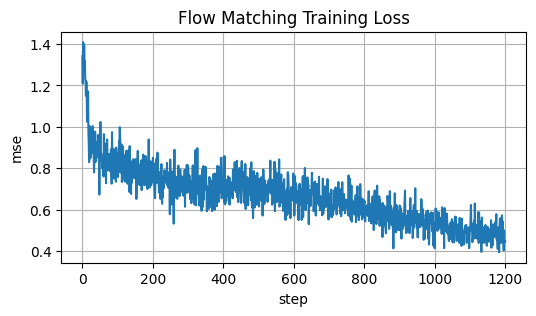

In [4]:
state_dim = 8
action_dim = 2
max_action = 1.0

states, actions = build_multimodal_dataset(
    n=6000,
    state_dim=state_dim,
    action_dim=action_dim,
    max_action=max_action,
    device=DEVICE,
)

model = FlowPolicyNet(state_dim=state_dim, action_dim=action_dim, time_dim=64, hidden=256).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

steps = 1200
batch_size = 256
loss_history = []

for step in range(steps):
    idx = torch.randint(0, states.size(0), (batch_size,), device=DEVICE)
    s_b = states[idx]
    a_b = actions[idx]

    loss = flow_matching_loss(model, s_b, a_b)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(float(loss.detach().cpu()))
    if (step + 1) % 200 == 0:
        print(f"step={step+1:04d}, loss={loss_history[-1]:.6f}")

plt.figure(figsize=(6, 3))
plt.plot(loss_history)
plt.title("Flow Matching Training Loss")
plt.xlabel("step")
plt.ylabel("mse")
plt.grid(True)
plt.show()

## 5. 采样与结果可视化

推理时给定状态 $s$，从基础分布采样初值动作 $a_0\sim\mathcal N(0,I)$，再积分 ODE 到 $t=1$：

$$
a_1 = a_0 + \int_0^1 v_\theta(a_t,t,s)\,dt
$$

这里使用前向 Euler 离散积分近似。

pred shape: (1000, 2) gt shape: (1000, 2)
pred min/max: -1.0 1.0


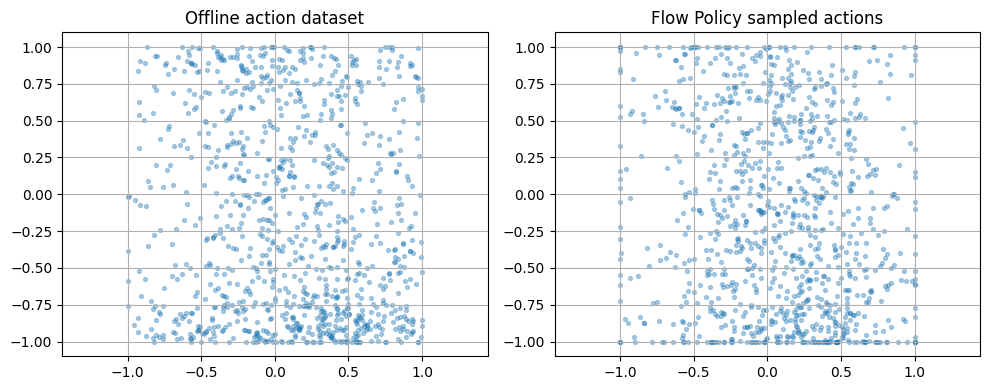

In [5]:
with torch.no_grad():
    test_s = states[:1000]
    pred_a = euler_sample_actions(model, test_s, action_dim=action_dim, n_steps=50, max_action=max_action)
    gt_a = actions[:1000]

print("pred shape:", tuple(pred_a.shape), "gt shape:", tuple(gt_a.shape))
print("pred min/max:", float(pred_a.min()), float(pred_a.max()))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(gt_a[:, 0].detach().cpu(), gt_a[:, 1].detach().cpu(), s=8, alpha=0.35)
plt.title("Offline action dataset")
plt.axis("equal")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(pred_a[:, 0].detach().cpu(), pred_a[:, 1].detach().cpu(), s=8, alpha=0.35)
plt.title("Flow Policy sampled actions")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Flow-Matching Policy 在强化学习中的常见算法与目标函数

### 6.1 FM-BC（纯离线行为克隆）

直接最小化 Flow Matching 损失：

$$
\min_\theta\;\mathcal L_{FM}(\theta)=\mathbb E\left[\|v_\theta(a_t,t,s)-(a^*-a_0)\|_2^2\right]
$$

其中 $(s,a^*)\sim\mathcal D$，$a_0\sim p_{base}$，$a_t=(1-t)a_0+t a^*$。

### 6.2 Advantage-Weighted FM（AWR/AWAC 思路）

对样本加权：

$$
\min_\theta\;\mathbb E\left[w(s,a^*)\cdot\|v_\theta(a_t,t,s)-(a^*-a_0)\|_2^2\right]
$$

$$
w(s,a^*)=\exp\left(\frac{A(s,a^*)}{\lambda}\right)
$$

常做截断：$w\leftarrow\min(w,w_{max})$。

### 6.3 Q-guided FM Actor（Actor-Critic）

把采样动作写为 $a=f_\theta(s,\xi)$（由 ODE 积分得到），最大化 critic 价值：

$$
\max_\theta\;J_{actor}(\theta)=\mathbb E_{s,\xi}[Q_\phi(s,f_\theta(s,\xi))]
$$

等价损失：

$$
\mathcal L_{actor}(\theta)=-\mathbb E_{s,\xi}[Q_\phi(s,f_\theta(s,\xi))]
$$

工程上常与 $\mathcal L_{FM}$ 联合：

$$
\mathcal L(\theta)=\mathcal L_{actor}(\theta)+\alpha\,\mathcal L_{FM}(\theta)
$$

### 6.4 KL-Regularized Flow Policy

用参考策略 $\pi_{ref}$（通常为 BC 预训练策略）做约束：

$$
\max_\theta\;\mathbb E_{s,a\sim\pi_\theta}[Q_\phi(s,a)]-\beta\,\mathrm{KL}(\pi_\theta(\cdot|s)\|\pi_{ref}(\cdot|s))
$$

当显式密度难算时，可用采样近似 KL，或以“行为克隆正则项”替代。

## 7. 策略分布、动作概率密度梯度与策略梯度计算

这一节回答三个问题：
1. Flow Policy 的策略分布 $\pi_\theta(a\mid s)$ 如何写？
2. 动作概率密度梯度（score）$\nabla_a\log\pi_\theta(a\mid s)$ 如何得到？
3. 策略梯度 $\nabla_\theta J(\theta)$ 怎么算？

### 7.1 策略分布（CNF 视角）

给定状态 $s$，动作轨迹由 ODE 定义：

$$
\frac{da_t}{dt}=v_\theta(a_t,t,s),\quad a_0\sim p_0(a)
$$

终点 $a_1$ 的分布就是策略分布 $\pi_\theta(a\mid s)$。

在连续归一化流（CNF）中，沿轨迹的对数密度满足：

$$
\frac{d}{dt}\log p_t(a_t\mid s)=-\nabla_a\cdot v_\theta(a_t,t,s)
$$

积分后得到：

$$
\log \pi_\theta(a_1\mid s)=\log p_0(a_0)-\int_0^1 \nabla_a\cdot v_\theta(a_t,t,s)\,dt
$$

这给出了“可计算密度”的理论基础（尽管实际计算可能昂贵）。

### 7.2 动作概率密度梯度（score）

定义 score：

$$
\mathbf g(a,s)=\nabla_a\log \pi_\theta(a\mid s)
$$

在 CNF 中可通过两类方式得到：
- **数值方式**：把 $\log\pi_\theta(a\mid s)$ 当标量函数，对动作 $a$ 用自动求导求梯度。
- **伴随/敏感度方式**：联立状态与雅可比（或其迹估计）一起积分，得到 score。

实践中高维动作常用迹估计（如 Hutchinson）近似散度项，降低计算量。

### 7.3 策略梯度怎么计算

#### 方法 A：路径导数（Pathwise，最常用）

把动作写成可导采样函数：

$$
a=f_\theta(s,\xi),\quad \xi\sim p(\xi)
$$

如果目标是最大化 $Q_\phi(s,a)$，则：

$$
\nabla_\theta J(\theta)=\nabla_\theta \mathbb E_{s,\xi}[Q_\phi(s,f_\theta(s,\xi))]
=\mathbb E\left[\nabla_a Q_\phi(s,a)\big\rvert_{a=f_\theta}\;\nabla_\theta f_\theta(s,\xi)\right]
$$

对应最小化损失：

$$
\mathcal L_{actor}(\theta)=-\mathbb E_{s,\xi}[Q_\phi(s,f_\theta(s,\xi))]
$$

这就是当前 Flow Policy 在 RL 中最主流的梯度计算方式。

#### 方法 B：似然比梯度（Likelihood-ratio）

若能稳定计算 $\log\pi_\theta(a\mid s)$，可用：

$$
\nabla_\theta J(\theta)=\mathbb E\left[\nabla_\theta\log\pi_\theta(a\mid s)\,\hat A(s,a)\right]
$$

优点：不要求环境可导；缺点：方差大，且对 flow 的显式密度计算成本高。

### 7.4 工程建议

- 先用 FM-BC 预训练得到稳定初始化。
- RL 微调时优先使用 **路径导数 + critic**。
- 需要显式熵/KL 约束时，再引入 log-density（配合迹估计）。

In [6]:
# 示例：如何在代码里计算 Flow Policy 的“路径导数策略梯度”

class TinyCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, s, a):
        return self.net(torch.cat([s, a], dim=-1))


def euler_sample_actions_with_grad(model, s, action_dim, n_steps=30):
    # 与前面的采样一致，但不加 no_grad，保留计算图以便对 theta 反传
    bsz = s.shape[0]
    a = torch.randn(bsz, action_dim, device=s.device)
    dt = 1.0 / n_steps
    for k in range(n_steps):
        t = torch.full((bsz, 1), k * dt, device=s.device)
        v = model(a, t, s)
        a = a + dt * v
    return a


critic = TinyCritic(state_dim=state_dim, action_dim=action_dim).to(DEVICE)
actor_opt = torch.optim.Adam(model.parameters(), lr=1e-4)

# 取一个 batch 的状态
idx = torch.randint(0, states.size(0), (128,), device=DEVICE)
s_actor = states[idx]

# 路径导数：a_theta = f_theta(s, xi)
a_theta = euler_sample_actions_with_grad(model, s_actor, action_dim=action_dim, n_steps=30)

# actor 目标：最大化 Q，等价最小化 -Q
actor_loss = -critic(s_actor, a_theta).mean()

actor_opt.zero_grad()
actor_loss.backward()
actor_opt.step()

print("pathwise actor loss:", float(actor_loss.detach().cpu()))
print("grad norm (first layer):", float(model.net[0].weight.grad.norm().detach().cpu()))

pathwise actor loss: 0.016449429094791412
grad norm (first layer): 0.02537945657968521


In [ ]:
# 可选：Q-guided Flow Policy 训练伪代码（示意）

def actor_loss_q_guided(model, critic, s, action_dim, n_steps=30, alpha_fm=0.1, a_star=None):
    """
    仅示意损失构成：
      L_actor = -E[Q(s, a_theta)] + alpha_fm * L_FM
    """
    a_theta = euler_sample_actions(model, s, action_dim=action_dim, n_steps=n_steps)
    loss_q = -critic(s, a_theta).mean()

    if a_star is None:
        return loss_q

    loss_bc = flow_matching_loss(model, s, a_star)
    return loss_q + alpha_fm * loss_bc

## 8. 小结：什么时候用哪种梯度

- **默认首选**：路径导数（Pathwise）
  - 采样过程可导，直接对 actor 参数反传，稳定且高效。
- **需要显式概率约束时**（熵/KL/可信域）
  - 再考虑显式 $\log\pi_\theta$ 与似然比梯度。
- **高维动作场景**
  - 计算散度与 log-density 成本高，优先用 Q-guided + FM 正则的组合目标。